In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("data/transactions_clean.csv", parse_dates=["ts"])
df = df.sort_values("ts").reset_index(drop=True)

print(f"Shape     : {df.shape}")
print(f"Fraud rate: {df.is_fraud.mean():.2%}")
print(f"Date range: {df.ts.min().date()} → {df.ts.max().date()}")

Shape     : (50000, 19)
Fraud rate: 4.29%
Date range: 2024-01-01 → 2024-12-30


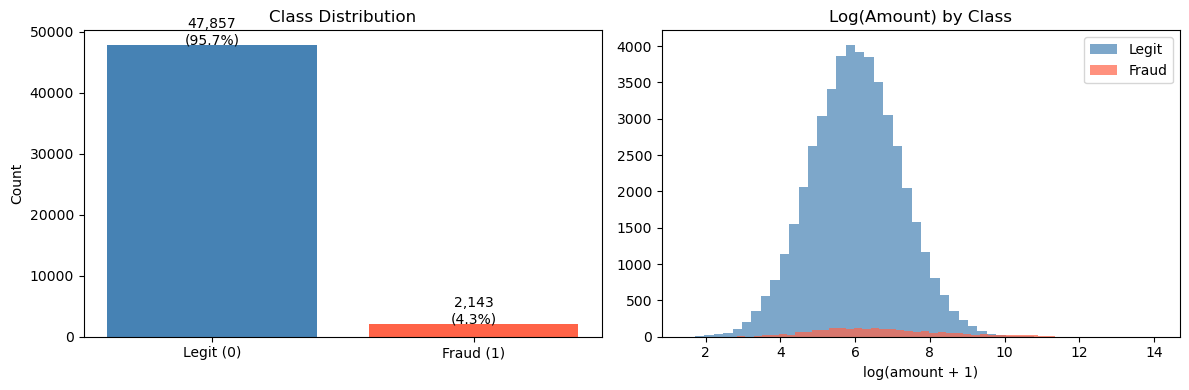

Fraud transactions are higher in amount on average


In [2]:
counts = df.is_fraud.value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(["Legit (0)", "Fraud (1)"], counts.values, color=["steelblue","tomato"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center")

# Amount by class
axes[1].hist(np.log1p(df[df.is_fraud==0]["amount"]), bins=50, alpha=0.7, label="Legit", color="steelblue")
axes[1].hist(np.log1p(df[df.is_fraud==1]["amount"]), bins=50, alpha=0.7, label="Fraud", color="tomato")
axes[1].set_title("Log(Amount) by Class")
axes[1].set_xlabel("log(amount + 1)")
axes[1].legend()

plt.tight_layout()
plt.savefig("data/eda_class_dist.png", dpi=100)
plt.show()
print("Fraud transactions are higher in amount on average")

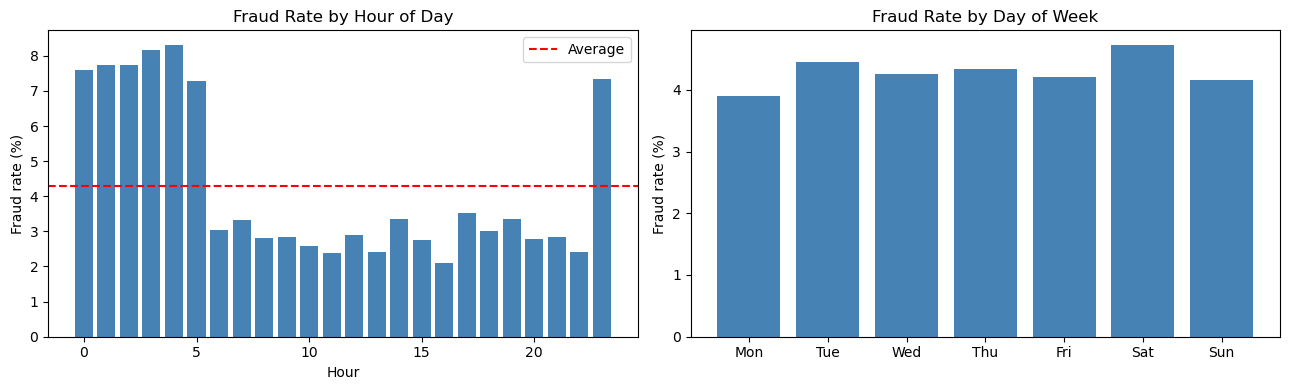

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

hourly = df.groupby("hour")["is_fraud"].mean()
axes[0].bar(hourly.index, hourly.values * 100, color="steelblue")
axes[0].set_title("Fraud Rate by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Fraud rate (%)")
axes[0].axhline(df.is_fraud.mean() * 100, color="red", linestyle="--", label="Average")
axes[0].legend()

dow_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily = df.groupby("dayofweek")["is_fraud"].mean()
axes[1].bar(dow_names, daily.values * 100, color="steelblue")
axes[1].set_title("Fraud Rate by Day of Week")
axes[1].set_ylabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

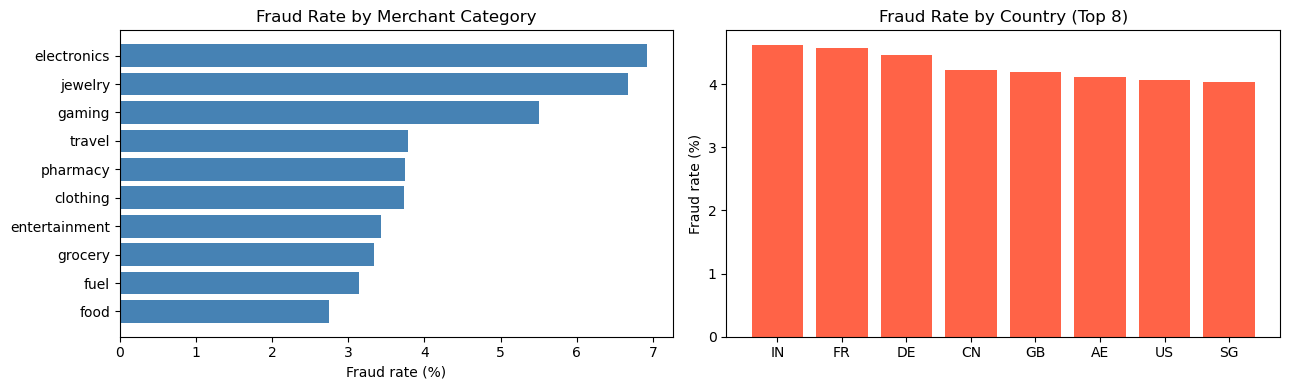

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cat_fraud = df.groupby("merchant_cat")["is_fraud"].mean().sort_values(ascending=True)
axes[0].barh(cat_fraud.index, cat_fraud.values * 100, color="steelblue")
axes[0].set_title("Fraud Rate by Merchant Category")
axes[0].set_xlabel("Fraud rate (%)")

country_fraud = df.groupby("country")["is_fraud"].mean().sort_values(ascending=False).head(8)
axes[1].bar(country_fraud.index, country_fraud.values * 100, color="tomato")
axes[1].set_title("Fraud Rate by Country (Top 8)")
axes[1].set_ylabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

In [5]:
CUT = int(len(df) * 0.80)
train = df.iloc[:CUT].copy()
valid = df.iloc[CUT:].copy()

print(f"Split date : {df.iloc[CUT]['ts'].date()}")
print(f"Train      : {len(train):,} rows | Fraud: {train.is_fraud.mean():.2%}")
print(f"Valid      : {len(valid):,} rows | Fraud: {valid.is_fraud.mean():.2%}")

Split date : 2024-10-19
Train      : 40,000 rows | Fraud: 4.30%
Valid      : 10,000 rows | Fraud: 4.22%


In [6]:
def add_features(df):
    df = df.copy()

    # Log transform — reduces skew
    df["log_amount"] = np.log1p(df["amount"])

    # 24h average transaction amount per card
    df["avg_tx_amt_24h"] = df["prev_24h_amt_card"] / (df["prev_24h_tx_count_card"] + 1e-3)

    # Velocity ratio: how much faster than usual?
    df["velocity_ratio"] = df["velocity_amt_1h"] / (df["avg_tx_amt_24h"] + 1e-3)

    # Amount vs 24h behavior (z-score style)
    df["amount_vs_24h_zscore"] = (df["amount"] - df["avg_tx_amt_24h"]) / (df["avg_tx_amt_24h"] + 1e-3)

    # Weekend flag
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

    # High velocity flag
    df["high_velocity_flag"] = (df["prev_1h_tx_count_card"] > 3).astype(int)

    # Rare merchant category
    cat_counts = df["merchant_cat"].value_counts()
    df["merchant_cat_rare"] = df["merchant_cat"].map(lambda x: int(cat_counts.get(x, 0) < 50))

    return df

train = add_features(train)
valid = add_features(valid)
print("✅ Features added")
print("New features:", ["log_amount","avg_tx_amt_24h","velocity_ratio",
                        "amount_vs_24h_zscore","is_weekend","high_velocity_flag","merchant_cat_rare"])

✅ Features added
New features: ['log_amount', 'avg_tx_amt_24h', 'velocity_ratio', 'amount_vs_24h_zscore', 'is_weekend', 'high_velocity_flag', 'merchant_cat_rare']


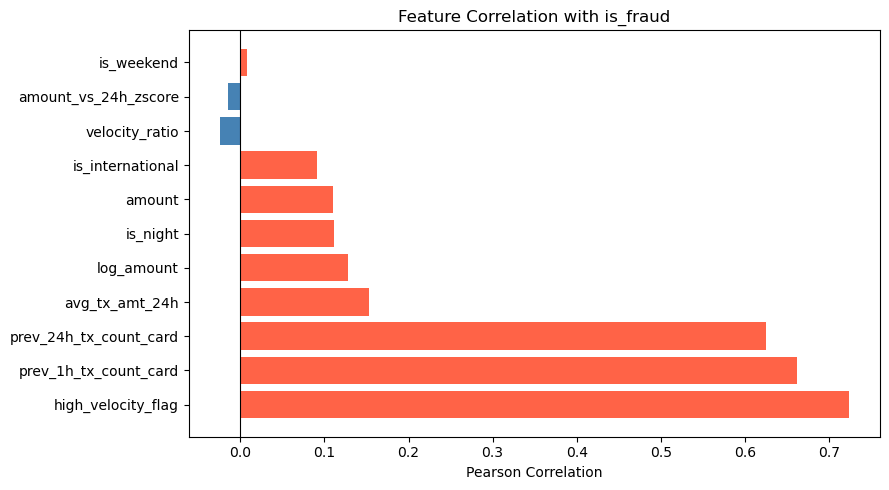

high_velocity_flag        0.723
prev_1h_tx_count_card     0.662
prev_24h_tx_count_card    0.625
avg_tx_amt_24h            0.153
log_amount                0.129
is_night                  0.112
amount                    0.110
is_international          0.091
velocity_ratio           -0.024
amount_vs_24h_zscore     -0.014
is_weekend                0.008
Name: is_fraud, dtype: float64


In [7]:
num_cols = ["amount","log_amount","velocity_ratio","avg_tx_amt_24h",
             "amount_vs_24h_zscore","prev_1h_tx_count_card","prev_24h_tx_count_card",
             "is_night","is_international","high_velocity_flag","is_weekend"]

corr = train[num_cols + ["is_fraud"]].corr()["is_fraud"].drop("is_fraud").sort_values(key=abs, ascending=False)

plt.figure(figsize=(9, 5))
colors = ["tomato" if v > 0 else "steelblue" for v in corr.values]
plt.barh(corr.index, corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with is_fraud")
plt.xlabel("Pearson Correlation")
plt.tight_layout()
plt.show()
print(corr.round(3))